# ML Analysis: Predicting Salaries in the AI & Data Science Job Market

This notebook applies machine learning models to predict salary levels based on job-related features such as experience level, skills, company size, and work type.

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("AI_Job_Market_Trends_2026.csv")
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


# Data Preprocessing

Categorical variables are encoded into numerical values to make them suitable for machine learning models.

In [79]:
le = LabelEncoder()

cat_cols = ["job_title", "company_size", "company_industry",
            "country", "remote_type", "experience_level",
            "education_level", "hiring_urgency"]

df_ml = df.copy()
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

features = ["experience_level", "years_experience", "company_size",
            "remote_type", "education_level", "skills_python",
            "skills_sql", "skills_ml", "skills_deep_learning", "skills_cloud"]

X = df_ml[features]
y = df_ml["salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (8276, 10)
Test set size: (2069, 10)


## Model 1: Linear Regression

Linear Regression is used as a baseline model to predict salary based on job-related features.


In [80]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results:")
print(f"  RMSE: {rmse_lr:.2f}")
print(f"  R² Score: {r2_lr:.4f}")

Linear Regression Results:
  RMSE: 20900.96
  R² Score: 0.5613


## Model 2: Random Forest

Random Forest is an ensemble learning method that builds multiple decision trees to improve prediction accuracy.

In [81]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R² Score: {r2_rf:.4f}")

Random Forest Results:
  RMSE: 21024.15
  R² Score: 0.5561


## Model Comparison

The two models are compared based on RMSE and R² scores to evaluate their performance.

               Model          RMSE  R² Score
0  Linear Regression  20900.962565  0.561261
1      Random Forest  21024.151283  0.556074


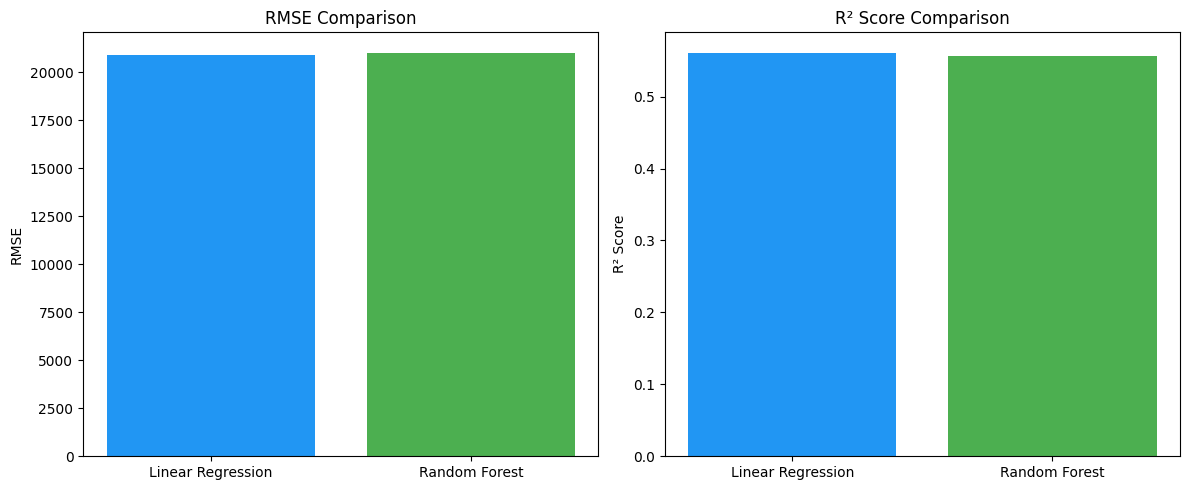

In [82]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

print(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(results["Model"], results["RMSE"], color=["#2196F3", "#4CAF50"])
axes[0].set_title("RMSE Comparison")
axes[0].set_ylabel("RMSE")

axes[1].bar(results["Model"], results["R² Score"], color=["#2196F3", "#4CAF50"])
axes[1].set_title("R² Score Comparison")
axes[1].set_ylabel("R² Score")

plt.tight_layout()
plt.show()

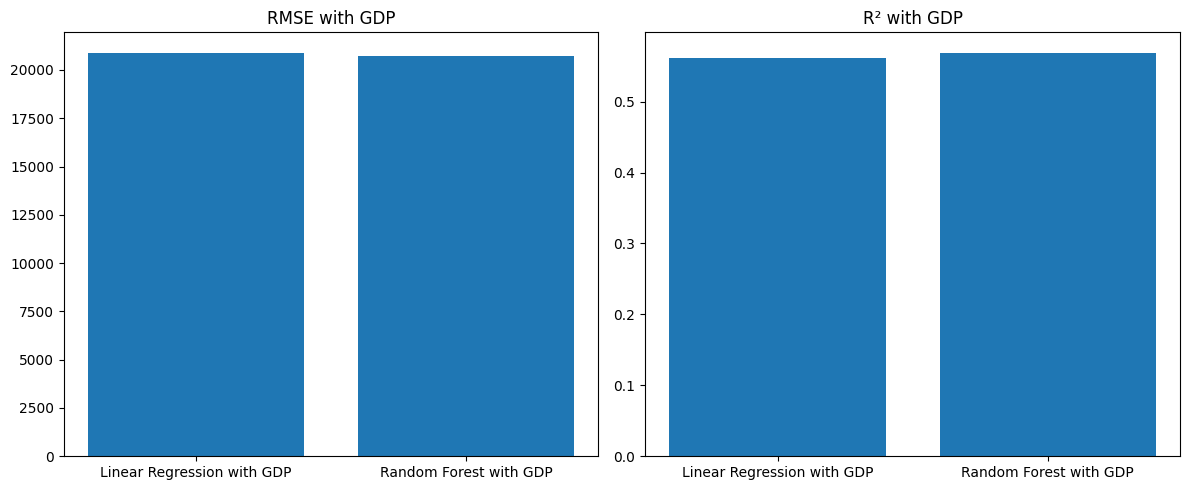

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(gdp_results["Model"], gdp_results["RMSE"])
axes[0].set_title("RMSE with GDP")

axes[1].bar(gdp_results["Model"], gdp_results["R² Score"])
axes[1].set_title("R² with GDP")

plt.tight_layout()
plt.show()

## Feature Importance

This section identifies which features have the most influence on salary prediction according to the Random Forest model.

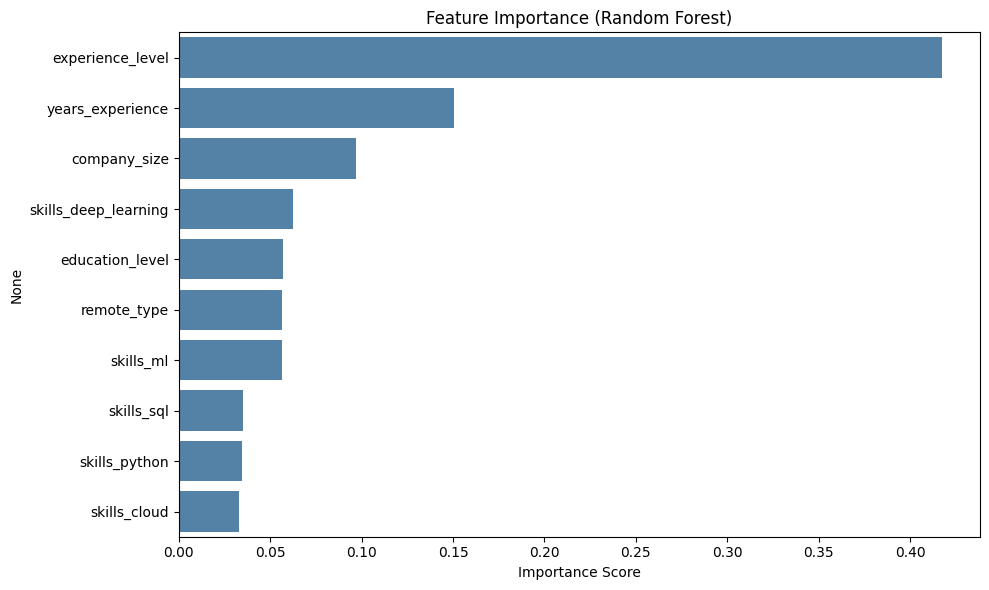

In [84]:
importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance.values, y=importance.index, color="steelblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## Conclusion

Both models achieved similar performance, with Linear Regression slightly outperforming Random Forest.

| Model | RMSE | R² Score |
|---|---|---|
| Linear Regression | 20900.96 | 0.5613 |
| Random Forest | 21024.15 | 0.5561 |

The feature importance analysis confirms that **experience_level** is by far the most influential factor in predicting salary, followed by years_experience and company_size. This is consistent with the hypothesis testing results from the EDA phase.

Technical skills such as Python, SQL, and cloud computing have relatively lower importance scores, suggesting that experience and seniority matter more than individual skill sets when it comes to salary determination.

## Linear Regression Coefficients

This section reports the coefficients of the Linear Regression model to better understand how each feature contributes to salary prediction.

             Feature  Coefficient
    experience_level 24575.427463
skills_deep_learning 15490.339219
           skills_ml 14748.870016
        skills_cloud  9900.404982
       skills_python   555.646255
     education_level   311.606379
         remote_type   136.927458
    years_experience   -75.407542
          skills_sql  -200.777225
        company_size -1866.039792


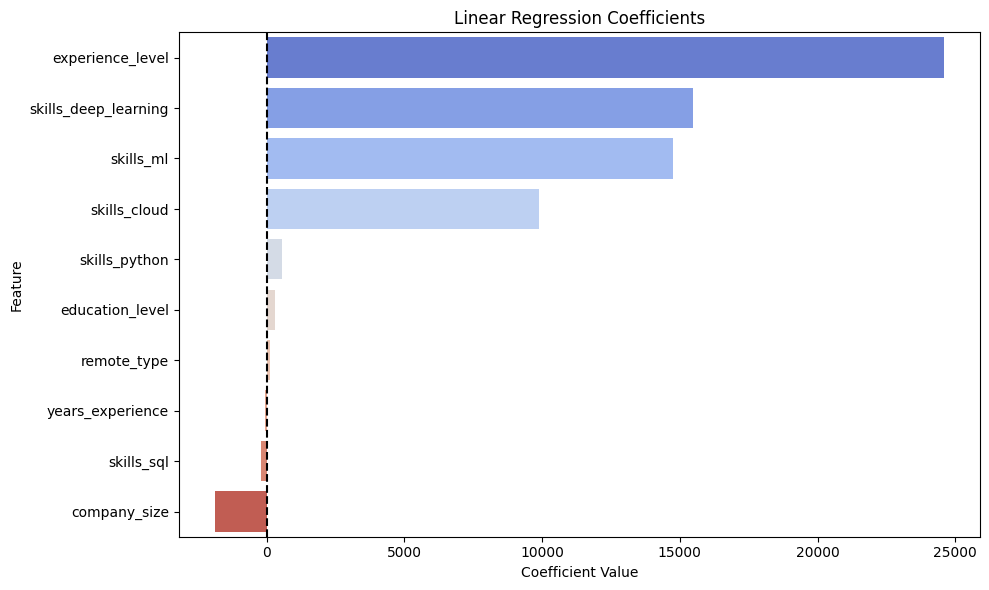

In [85]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

print(coefficients.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x="Coefficient", y="Feature", data=coefficients,
            hue="Feature", palette="coolwarm", legend=False)
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(x=0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

### Interpretation of Coefficients

The coefficients show how each feature affects salary in a linear model.

- Experience level has the largest positive impact on salary
- Skills such as deep learning and machine learning also contribute positively
- Some variables such as company size and SQL show weaker or negative effects

This indicates that experience remains the strongest predictor of salary, while technical skills have a more moderate influence.

## Model Interpretation: Why did Linear Regression outperform Random Forest?

The difference in R² scores between Linear Regression (0.5613) and Random Forest (0.5561) is very small (0.005), meaning both models perform similarly in practice.

This result suggests that the relationship between the features and salary is largely linear. When the underlying relationship is linear, Random Forest does not offer a significant advantage over Linear Regression and may even slightly underperform due to overfitting on training data.

Overall, both models explain approximately 56% of the variance in salary, indicating that the selected features capture a meaningful portion of salary variation, while other unobserved factors may account for the remaining variance.

## Data Enrichment with GDP per Capita

To improve the analysis, external economic data is incorporated into the dataset. GDP per capita is used as an additional feature to capture country-level economic differences that may influence salary levels.

In [86]:
gdp_df = pd.read_csv("API_NY.GDP.PCAP.CD_DS2_en_csv_v2_121663.csv", skiprows=4)

gdp_df = gdp_df[["Country Name", "2023"]].rename(
    columns={"Country Name": "country", "2023": "gdp_per_capita"}
)

gdp_df = gdp_df.dropna(subset=["gdp_per_capita"])

print(gdp_df.head())
print("Shape:", gdp_df.shape)

                       country  gdp_per_capita
0                        Aruba    35718.753119
1  Africa Eastern and Southern     1571.449189
2                  Afghanistan      413.757895
3   Africa Western and Central     1841.855064
4                       Angola     2916.136633
Shape: (251, 2)


### GDP Data Preparation

The GDP dataset is cleaned by selecting the country names and the most recent available year (2023). Missing values are removed to ensure data quality before merging.

In [87]:
df_enriched = df.merge(gdp_df, on="country", how="left")

print(df_enriched[["country", "gdp_per_capita"]].head())
print("Missing GDP values:", df_enriched["gdp_per_capita"].isnull().sum())

     country  gdp_per_capita
0     Canada    54220.328504
1  Australia    65058.377315
2    Germany    54776.766824
3    Germany    54776.766824
4    Germany    54776.766824
Missing GDP values: 2944


### Merging Datasets

The GDP data is merged with the main dataset using the country variable. This allows each job entry to be associated with the economic condition of its respective country.

In [88]:

df_enriched["gdp_per_capita"] = df_enriched["gdp_per_capita"].fillna(
    df_enriched["gdp_per_capita"].median()
)

print("Missing GDP after filling:", df_enriched["gdp_per_capita"].isnull().sum())

Missing GDP after filling: 0


### Handling Missing Values

Some countries may not match exactly between datasets, resulting in missing GDP values. These values are filled using the median GDP to maintain consistency in the dataset.

In [89]:
df_enriched_ml = df_enriched.copy()

for col in cat_cols:
    df_enriched_ml[col] = le.fit_transform(df_enriched_ml[col])

features_gdp = features + ["gdp_per_capita"]

X_gdp = df_enriched_ml[features_gdp]
y_gdp = df_enriched_ml["salary"]

X_train_gdp, X_test_gdp, y_train_gdp, y_test_gdp = train_test_split(
    X_gdp, y_gdp, test_size=0.2, random_state=42
)

print("Training set size:", X_train_gdp.shape)
print("Test set size:", X_test_gdp.shape)


Training set size: (8276, 11)
Test set size: (2069, 11)


In [90]:
lr_gdp = LinearRegression()
lr_gdp.fit(X_train_gdp, y_train_gdp)

y_pred_lr_gdp = lr_gdp.predict(X_test_gdp)

rmse_lr_gdp = np.sqrt(mean_squared_error(y_test_gdp, y_pred_lr_gdp))
r2_lr_gdp = r2_score(y_test_gdp, y_pred_lr_gdp)

print("Linear Regression with GDP Results:")
print(f"RMSE: {rmse_lr_gdp:.2f}")
print(f"R² Score: {r2_lr_gdp:.4f}")

Linear Regression with GDP Results:
RMSE: 20904.65
R² Score: 0.5611


In [91]:
rf_gdp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_gdp.fit(X_train_gdp, y_train_gdp)

y_pred_rf_gdp = rf_gdp.predict(X_test_gdp)

rmse_rf_gdp = np.sqrt(mean_squared_error(y_test_gdp, y_pred_rf_gdp))
r2_rf_gdp = r2_score(y_test_gdp, y_pred_rf_gdp)

print("Random Forest with GDP Results:")
print(f"RMSE: {rmse_rf_gdp:.2f}")
print(f"R² Score: {r2_rf_gdp:.4f}")

Random Forest with GDP Results:
RMSE: 20710.22
R² Score: 0.5692


## Machine Learning with Enriched Data

After adding GDP per capita as a new feature, the models are retrained to evaluate whether external economic factors improve salary prediction performance.

In [92]:
print(df_enriched[["salary", "gdp_per_capita"]].corr())

                  salary  gdp_per_capita
salary          1.000000        0.018535
gdp_per_capita  0.018535        1.000000


### GDP and Salary Relationship

The correlation between GDP per capita and salary is relatively weak (~0.018), suggesting that country-level economic conditions have only a minor direct effect on salaries compared to job-specific factors.

## Impact of GDP Enrichment

The inclusion of GDP per capita provides additional context about economic differences between countries.

If model performance improves, it indicates that macroeconomic conditions play a role in salary determination. If the improvement is limited, it suggests that job-specific features such as experience remain the dominant factors.

In [93]:
gdp_results = pd.DataFrame({
    "Model": ["Linear Regression with GDP", "Random Forest with GDP"],
    "RMSE": [rmse_lr_gdp, rmse_rf_gdp],
    "R² Score": [r2_lr_gdp, r2_rf_gdp]
})

print(gdp_results)

                        Model          RMSE  R² Score
0  Linear Regression with GDP  20904.645336  0.561107
1      Random Forest with GDP  20710.217251  0.569233


### Comparison Before and After Enrichment

Before adding GDP per capita:
- Linear Regression R²: 0.5613
- Random Forest R²: 0.5561

After adding GDP per capita:
- Linear Regression R²: ~0.5611
- Random Forest R²: ~0.5692

This shows that GDP has a limited effect on Linear Regression, but slightly improves Random Forest performance, suggesting that economic conditions introduce some non-linear patterns.

## Final Conclusion

This project analyzed the key factors affecting salaries in the AI and data science job market using exploratory data analysis, hypothesis testing, and machine learning models.

The results consistently show that experience level is the most significant factor in determining salary, while technical skills and work type have a more limited impact. Both Linear Regression and Random Forest models achieved similar performance, indicating that the relationships in the dataset are largely linear.

The addition of GDP per capita as an external feature provided only a slight improvement in model performance, suggesting that country-level economic conditions have a secondary role compared to job-specific characteristics.

Overall, the findings highlight that salary is primarily driven by experience and structural factors rather than individual skills or macroeconomic indicators alone.

Although GDP per capita introduces additional context, its impact on model performance is minimal, confirming that salary prediction is primarily driven by job-specific factors rather than macroeconomic conditions.